In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler, PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, auc, roc_auc_score, r2_score, mean_squared_error
import statsmodels.api as sm
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn import tree
from sklearn.linear_model import Lasso
import bambi as bmb
import arviz as az

train_test_random_state = 123

In [374]:
def plotRelationships(axs, dataset, predictors, y):
    for i in range(len(predictors)):
        row = i // 2
        col = i % 2
        axs[row, col].scatter(dataset[predictors[i]], y)
        axs[row, col].set_title(f'{predictors[i]} vs. Stress level score')
        axs[row, col].set_xlabel(predictors[i])
        axs[row, col].set_ylabel('Stress level score')

In [255]:
def dropInsignificant(X, y):
	model = sm.OLS(y, X).fit()

	# Calculate reduced model
	mod_temp = model
	X_temp = X
	while max(mod_temp.pvalues[1:]) > 0.05 and (len(X_temp.columns) > 1):
		max_pvalue = np.argmax(mod_temp.pvalues[1:])+1
		X_temp = X_temp.drop(columns = X_temp.columns[max_pvalue])
		mod_temp = sm.OLS(y, X_temp).fit()
	model = mod_temp

	# Return reduced model
	return model, X_temp

In [256]:
def dropInsignificant(y, X):
	model = sm.OLS(y, X).fit()

	# Calculate reduced model
	mod_temp = model
	X_temp = X
	while max(mod_temp.pvalues[1:]) > 0.05 and (len(X_temp.columns) > 1):
		max_pvalue = np.argmax(mod_temp.pvalues[1:])+1
		X_temp = X_temp.drop(columns = X_temp.columns[max_pvalue])
		mod_temp = sm.OLS(y, X_temp).fit()
	model = mod_temp

	# Return reduced model with predictors
	return model, X_temp

In [257]:
def calculateR2(model, X, y):
	# Calculate r2
	y_pred = model.predict(X)
	r2 = r2_score(y, y_pred)
	return r2

In [299]:
def create_bambi_formula(df, response_var):
    # Get all column names excluding the response variable
    predictors = df.columns[df.columns != response_var]

    # Handle special characters in column names (e.g., spaces, %, etc.)
    predictors = [f"`{col}`" if not col.isidentifier() else col for col in predictors]

    # Join all predictors into a formula string
    formula = f"{response_var} ~ " + " + ".join(predictors)
    return formula

**Part 1**. In this analysis, we will explore a dataset from a health study designed to understand factors influencing individual stress levels. You can access the data set at

https://richardson.byu.edu/220/stress.csv

The dataset includes several predictors: Age, Occupation, Physical Activity Level, Sleep Quality, Daily Screen Time, Social Interactions, Financial Stress, and Diet Quality. The target variable is the Stress Level Score. Our objectives are to explore the data, fit various models, and interpret our findings.

Problem 1. Perform an exploratory data analysis. Plot the target variable as well as each other continuous variable. Does it seem like any need to be transformed by taking the log of the data?


In [375]:
# Import and show data
stress_data_raw = pd.read_csv('https://richardson.byu.edu/220/stress.csv')
stress_data_raw.head()

,age,occupation,physical_activity,sleep_quality,daily_screen_time,social_interactions,financial_stress,diet_quality,stress_level_score
0,65,Professional,Sedentary,9,7,2,4,Good,3.2
1,32,Retired,Sedentary,9,3,1,3,Excellent,0.8
2,37,Professional,Sedentary,9,7,2,5,Good,5.3
3,48,Professional,Light,10,4,3,3,Good,3.4
4,65,Unemployed,Moderate,9,3,1,9,Average,0.8


In [376]:
# Separate into X and y
target = 'stress_level_score'

X = stress_data_raw.drop(columns=target)
X_with_const = sm.add_constant(X)
y = stress_data_raw[target]

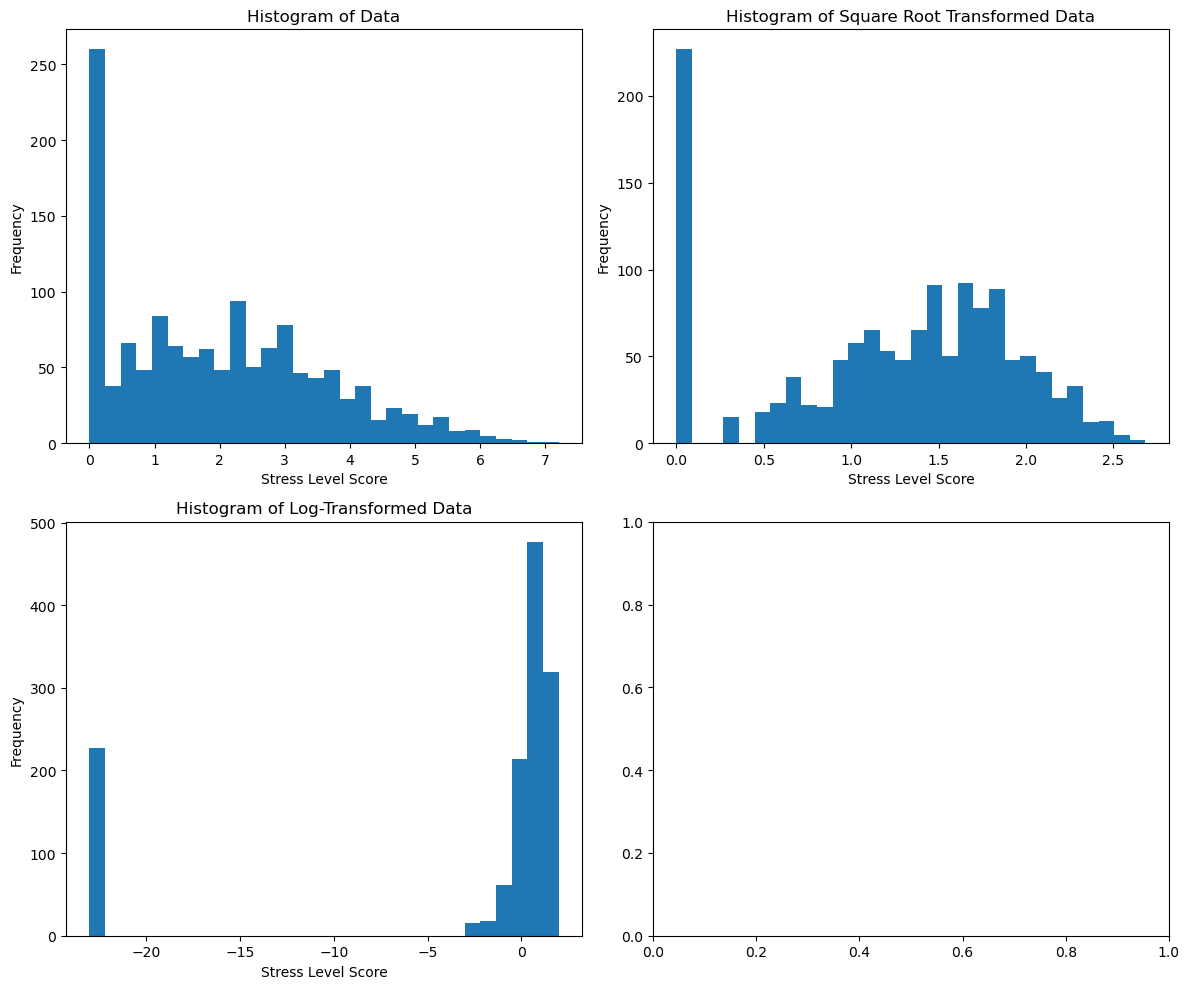

In [377]:
''' Plot target variable '''
# Create subplots
fig, axs = plt.subplots(2, 2, figsize=(12, 10))

# Plot original data histogram
axs[0][0].hist(y, bins=30)
axs[0][0].set_title('Histogram of Data')
axs[0][0].set_xlabel('Stress Level Score')
axs[0][0].set_ylabel('Frequency')

# Plot square root transformed data histogram
axs[0][1].hist(np.sqrt(y), bins=30)
axs[0][1].set_title('Histogram of Square Root Transformed Data')
axs[0][1].set_xlabel('Stress Level Score')
axs[0][1].set_ylabel('Frequency')

# Plot log-transformed data histogram
epsilon = 1e-10
axs[1][0].hist(np.log(y + epsilon), bins=30)
axs[1][0].set_title('Histogram of Log-Transformed Data')
axs[1][0].set_xlabel('Stress Level Score')
axs[1][0].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

> ### Explanation
> Because there are so many values equal to zero the log transformation isn't very effective. Also, because there are so many values between 0 and 1 the square root transformation isn't ideal. I would leave the target as is, the distrubution is skewed, but not to an extream.

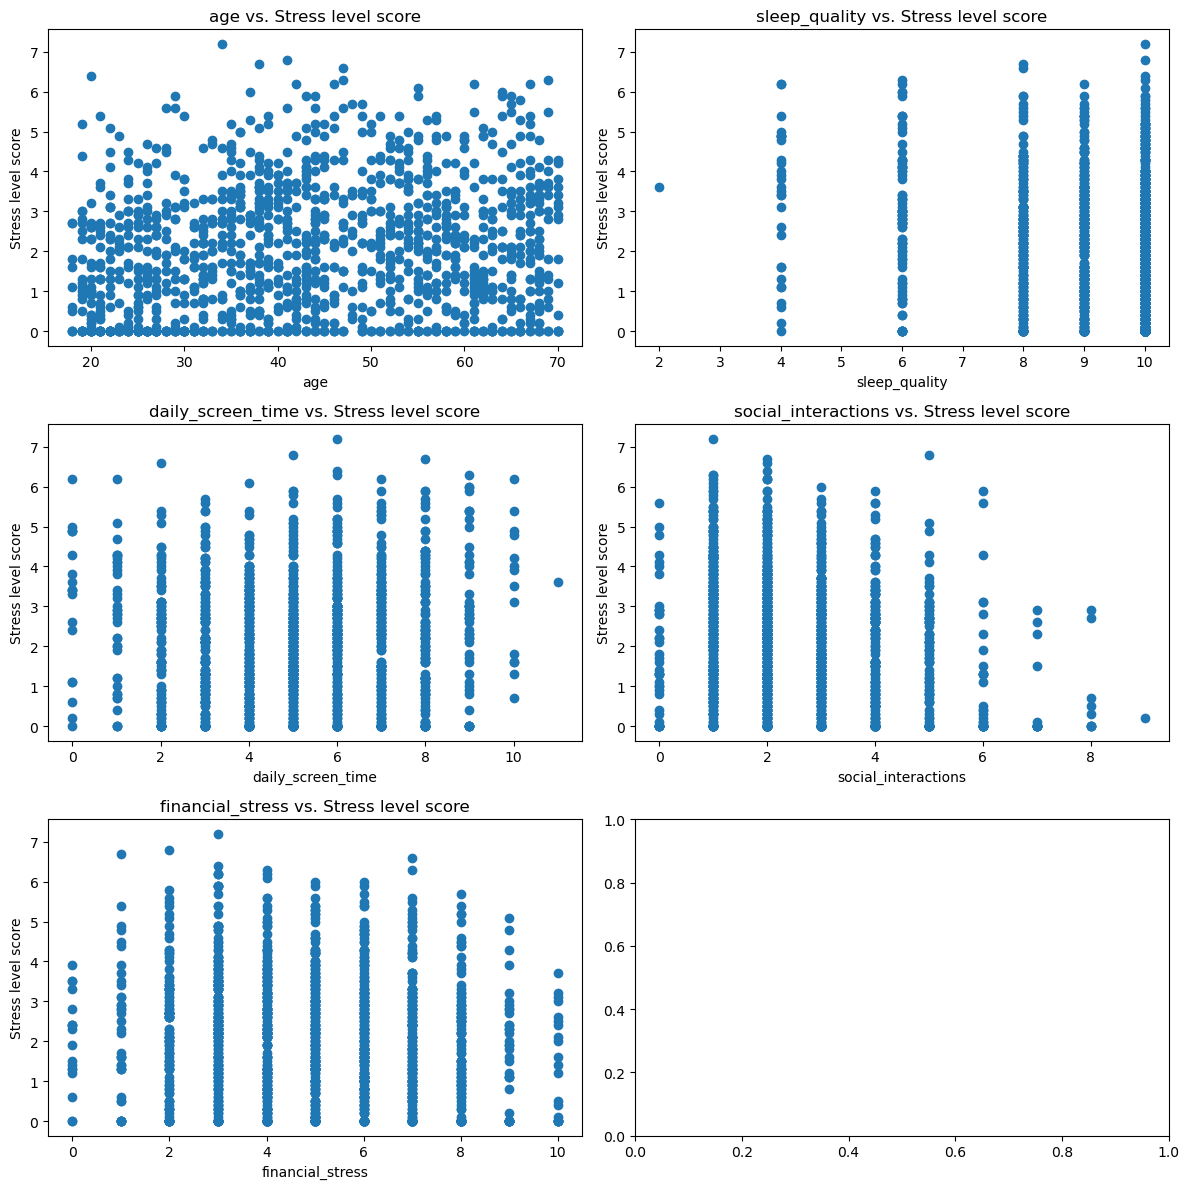

In [383]:
# Plot relationships between the continuous predictors and the target
continuous_cols = list(X.select_dtypes(include=[np.number]).columns)
fig, axs = plt.subplots(3, 2, figsize=(12, 12))
plotRelationships(axs, X, continuous_cols, y)

plt.tight_layout()
plt.show()

> ### Explanation
> All of the predictors seem alright without any transformation.

Problem 2. Prepare the data for a linear regression analysis by splitting the data into train and test groups, standardizing the continuous variables, and creating dummies for the categorical variables.

In [261]:
# Split into continuous and categorical
continuous_cols = X.select_dtypes(include=[np.number]).columns
categorical_cols = X.select_dtypes(include=[object]).columns

In [262]:
X_processed = X.copy()

# Standardize the continuous columns
scaler= StandardScaler()
X_processed[continuous_cols] = scaler.fit_transform(X_processed[continuous_cols])

# Dummify the categorical columns
X_processed = pd.get_dummies(X_processed, columns=categorical_cols, drop_first=True)

# Replace False with 0 and True with 1
X_processed = X_processed.replace({False: 0, True: 1})
X_processed_with_const = sm.add_constant(X_processed)

In [63]:
# Show processed predictors
X_processed_with_const.head()

,const,age,sleep_quality,daily_screen_time,social_interactions,financial_stress,occupation_Retired,occupation_Student,occupation_Unemployed,physical_activity_Light,physical_activity_Moderate,physical_activity_Sedentary,diet_quality_Excellent,diet_quality_Good,diet_quality_Poor
0,1.0,1.410805,-0.083316,0.922033,-0.407263,-0.470546,0,0,0,0,0,1,0,1,0
1,1.0,-0.780848,-0.083316,-1.005295,-1.065911,-0.937932,1,0,0,0,0,1,1,0,0
2,1.0,-0.448779,-0.083316,0.922033,-0.407263,-0.003160,0,0,0,0,0,1,0,1,0
3,1.0,0.281772,0.651076,-0.523463,0.251385,-0.937932,0,0,0,1,0,0,0,1,0
4,1.0,1.410805,-0.083316,-1.005295,-1.065911,1.866383,0,0,1,0,1,0,0,0,0


In [190]:
# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(X_processed_with_const, y, test_size=0.2, random_state=train_test_random_state)

Problem 3. Split the data into a train and test set. Fit a linear regression model with all the predictors on the train set. Remove variables so only significant features remain while confirming that the model performance improves by evaluating the model on the test set.

In [78]:
# Fit and test complete model
complete_reg = sm.OLS(y_train, X_train).fit()
complete_r2 = complete_reg.rsquared

# Fit and test reduced model
reduced_reg, X_reduced = dropInsignificant(y_train, X_train)
reduced_r2 = reduced_reg.rsquared

In [79]:
# Show results as a table
dict = {
    'Complete model': [complete_r2],
    'Reduced model': [reduced_r2],
}
df = pd.DataFrame(dict).T
df.columns = ['Out of sample R2']
df

,Out of sample R2
Complete model,0.174361
Reduced model,0.170838


In [88]:
print('----- Number of complete columns -----')
print(len(X_processed.columns))

----- Number of complete columns -----
14


In [89]:
print('----- Number of reduced columns -----')
print(len(X_reduced.columns))

----- Number of reduced columns -----
11


> ### Explanation
> The out of sample R2 doesn't change much when the 3 insignificant columns are dropped. This could be becasuse of the random train test split. But, generaly speaking, removing insignificant predictors will help the model avoid overfitting and improve the accuracy.

Problem 4. From the model in Problem 3, what is the confidence interval for the regression coefficient associated with age?

In [90]:
reduced_reg.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:     stress_level_score   R-squared:                       0.171
Model:                            OLS   Adj. R-squared:                  0.163
Method:                 Least Squares   F-statistic:                     21.70
Date:                Wed, 18 Dec 2024   Prob (F-statistic):           4.20e-37
Time:                        16:53:56   Log-Likelihood:                -1902.6
No. Observations:                1064   AIC:                             3827.
Df Residuals:                    1053   BIC:                             3882.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
===============================================================================================
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
const                           1.0594      0.147      7.224      0.000       0.772       1.347
age                             0.1630      0.051      3.194      0.001       0.063       0.263
sleep_quality                  -0.2680      0.046     -5.832      0.000      -0.358      -0.178
daily_screen_time               0.0887      0.045      1.991      0.047       0.001       0.176
social_interactions            -0.2162      0.052     -4.165      0.000      -0.318      -0.114
financial_stress               -0.1588      0.045     -3.521      0.000      -0.247      -0.070
physical_activity_Light         0.7644      0.161      4.743      0.000       0.448       1.081
physical_activity_Moderate      0.7345      0.175      4.196      0.000       0.391       1.078
physical_activity_Sedentary     1.2179      0.159      7.641      0.000       0.905       1.531
diet_quality_Good               0.1881      0.096      1.965      0.050       0.000       0.376
diet_quality_Poor               0.3575      0.156      2.290      0.022       0.051       0.664
==============================================================================
Omnibus:                       33.007   Durbin-Watson:                   2.080
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               35.631
Skew:                           0.446   Prob(JB):                     1.83e-08
Kurtosis:                       2.914   Cond. No.                         8.31
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

> ### Explanation
> The 95% confidence interval for the "age" coefficient of the reduced model is 0.063 to 0.263.

Problem 5. Test adding age^2 and social_interaction^2 into the model. Test adding an interaction between screen time and sleep quality. Test adding an interaction between social interaction and financial stress. Determine if the higher order terms you have tested are significant or not. Remove the interactions that are not. The final model you get from this problem will be used in several other problems, so keep track of it!

In [94]:
# Create higher order predictors
X_higher_order = X_processed_with_const.copy()

X_higher_order['age**2'] = np.power(X_higher_order['age'], 2)
X_higher_order['social_interactions**2'] = np.power(X_higher_order['social_interactions'], 2)
X_higher_order['daily_screen_time*sleep_quality'] = X_higher_order['daily_screen_time'] * X_higher_order['sleep_quality']
X_higher_order['social_interactions*financial_stress'] = X_higher_order['social_interactions'] * X_higher_order['financial_stress']

In [95]:
# Show higher order predictors
X_higher_order.head()

,const,age,sleep_quality,daily_screen_time,social_interactions,financial_stress,occupation_Retired,occupation_Student,occupation_Unemployed,physical_activity_Light,physical_activity_Moderate,physical_activity_Sedentary,diet_quality_Excellent,diet_quality_Good,diet_quality_Poor,age**2,social_interactions**2,daily_screen_time*sleep_quality,social_interactions*financial_stress
0,1.0,1.410805,-0.083316,0.922033,-0.407263,-0.470546,0,0,0,0,0,1,0,1,0,1.990370,0.165863,-0.076820,0.191636
1,1.0,-0.780848,-0.083316,-1.005295,-1.065911,-0.937932,1,0,0,0,0,1,1,0,0,0.609723,1.136167,0.083757,0.999752
2,1.0,-0.448779,-0.083316,0.922033,-0.407263,-0.003160,0,0,0,0,0,1,0,1,0,0.201403,0.165863,-0.076820,0.001287
3,1.0,0.281772,0.651076,-0.523463,0.251385,-0.937932,0,0,0,1,0,0,0,1,0,0.079395,0.063194,-0.340814,-0.235782
4,1.0,1.410805,-0.083316,-1.005295,-1.065911,1.866383,0,0,1,0,1,0,0,0,0,1.990370,1.136167,0.083757,-1.989399


In [197]:
# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(X_higher_order, y, test_size=0.2, random_state=train_test_random_state)

In [98]:
# Fit a reduced model
reduced_reg_higher_order, X_reduced = dropInsignificant(y_train, X_train)

In [99]:
reduced_reg_higher_order.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:     stress_level_score   R-squared:                       0.181
Model:                            OLS   Adj. R-squared:                  0.173
Method:                 Least Squares   F-statistic:                     23.29
Date:                Wed, 18 Dec 2024   Prob (F-statistic):           7.56e-40
Time:                        17:07:59   Log-Likelihood:                -1896.0
No. Observations:                1064   AIC:                             3814.
Df Residuals:                    1053   BIC:                             3869.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
========================================================================================================
                                           coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------
const                                    1.4361      0.153      9.385      0.000       1.136       1.736
age                                      0.1667      0.051      3.288      0.001       0.067       0.266
sleep_quality                           -0.2761      0.046     -6.060      0.000      -0.366      -0.187
social_interactions                     -0.2020      0.052     -3.903      0.000      -0.303      -0.100
financial_stress                        -0.1739      0.045     -3.854      0.000      -0.262      -0.085
occupation_Student                      -0.2184      0.108     -2.021      0.044      -0.430      -0.006
physical_activity_Light                  0.7580      0.160      4.729      0.000       0.443       1.072
physical_activity_Moderate               0.7347      0.174      4.223      0.000       0.393       1.076
physical_activity_Sedentary              1.1851      0.159      7.475      0.000       0.874       1.496
age**2                                  -0.1881      0.049     -3.820      0.000      -0.285      -0.091
social_interactions*financial_stress    -0.1127      0.045     -2.489      0.013      -0.201      -0.024
==============================================================================
Omnibus:                       34.171   Durbin-Watson:                   2.085
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               36.996
Skew:                           0.455   Prob(JB):                     9.26e-09
Kurtosis:                       2.911   Cond. No.                         11.2
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

> ### Explanation
> It appears that age^2 and social_interactions*financial_stress remain significant.

Problem 6. Start again using data with all the predictors and with all higher order terms listed in problem 5 (meaning even if your previous models removed variables, add them all back in). Perform a LASSO regression model. Tune the model to find a good LASSO parameter.

In [195]:
# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(X_higher_order, y, test_size=0.2, random_state=train_test_random_state)

In [179]:
# Set alpha for lasso
alpha = 0.001

In [178]:
# Scale y
scale_y = StandardScaler()
scale_y.fit(y_train.values.reshape(-1,1))
y_train_scaled = scale_y.transform(y_train.values.reshape(-1,1))

# Fit lasso model
reg_lasso = Lasso(alpha=alpha)
reg_lasso.fit(X_train, y_train_scaled)

# Find R^2 for the Lasso model
preds_lasso = scale_y.inverse_transform([reg_lasso.predict(X_test)])
in_preds = scale_y.inverse_transform([reg_lasso.predict(X_train)])

In [180]:
# Show results as a table
dict = {
    'In sample': [r2_score(y_train,in_preds[0])],
    'Out of sample': [r2_score(y_test,preds_lasso[0])],
}
df = pd.DataFrame(dict).T
df.columns = ['R2']
print(f'----- LASSO results for alpha = {alpha} -----')
df

----- LASSO results for alpha = 0.001 -----


,R2
In sample,0.189935
Out of sample,0.128539


Problem 7. Build a regression tree for the data. Choose either maximum depth or cost complexity parameter. Test several possible values. Use out of sample model fit to determine which of the values you tested is the best.

In [185]:
# Create lists
max_depths = []
tree_r2s = []

# Loop through the depths
for depth in range(2, 11):
	# Declare and fit tree
	tree_model = DecisionTreeRegressor(max_depth = depth)
	tree_model.fit(X_train, y_train)

	# Calculate r2 and append to list
	tree_r2 = calculateR2(tree_model, X_test, y_test)
	tree_r2s.append(tree_r2)

	# Append max depth
	max_depths.append(depth)

# Display r2s as a table
dic = {
    'Max depth': max_depths,
    'Out of sample R^2': tree_r2s,
}
df = pd.DataFrame(dic)
df

,Max depth,Out of sample R^2
0,2,0.049610
1,3,0.059641
2,4,-0.080601
3,5,-0.112549
4,6,-0.251229
5,7,-0.211099
6,8,-0.324060
7,9,-0.393924
8,10,-0.499987


In [222]:
tree_reg = DecisionTreeRegressor(max_depth=3)
tree_reg.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=3)

> ### Explanation
> I decided that a max depth of 3 would be the most effective.

Problem 8. You have built three tuned models, the linear regression model with potential higher order terms, a LASSO regression model, and a regression tree. Use out of sample MSE to determine which model is the best.

In [207]:
# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(X_higher_order[X_reduced.columns], y, test_size=0.2, random_state=train_test_random_state)

In [208]:
'''Find MSE for the linear regression model'''
# Make predictions
predictions = reduced_reg_higher_order.predict(X_test)

# Calculate MSE
linear_reg_mse = mean_squared_error(y_test, predictions)

In [212]:
# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(X_higher_order, y, test_size=0.2, random_state=train_test_random_state)

In [216]:
'''Find MSE for the LASSO model'''
# Make predictions
preds_lasso_scaled = reg_lasso.predict(X_test)
preds_lasso = scale_y.inverse_transform(preds_lasso_scaled.reshape(-1, 1))

# Calculate MSE
lasso_mse = mean_squared_error(y_test, preds_lasso)

In [218]:
'''Find MSE for the decision tree regressor'''
# Make predictions
preds_dt = tree_reg.predict(X_test)

# Calculate MSE
dt_mse = mean_squared_error(y_test, preds_dt)

In [219]:
# Display results as a table
dic = {
    'Linear regressor': [linear_reg_mse],
    'LASSO': [lasso_mse],
    'Decision tree': [dt_mse],
}
df = pd.DataFrame(dic).T
df.columns = ['MSE']
df

,MSE
Linear regressor,2.305253
LASSO,2.292139
Decision tree,2.473357


In [220]:
print('----- Standard deviation of the target -----')
print(np.std(y))

----- Standard deviation of the target -----
1.5953320259856256


> ### Explanation
> The model that has the most accurate MSE is the LASSO model

Problem 9. Use feature importances for the regression tree model, p values for the linear regression model, and the coefficients from the LASSO model, state three predictors you find to be important for predicting stress. State three variables you  find to be either not important for predicting stress, or at least not as important as other predictors. Justify your reasoning by refering to specific output from the models.

In [226]:
# Display p-values as a table in ascending order
p_values = reduced_reg_higher_order.pvalues
sorted_p_values = p_values.sort_values(ascending=True)
p_values_table = pd.DataFrame(sorted_p_values, columns=['P-value'])
p_values_table

,P-value
const,3.737577e-20
physical_activity_Sedentary,1.616048e-13
sleep_quality,1.892119e-09
physical_activity_Light,2.557238e-06
physical_activity_Moderate,2.621270e-05
social_interactions,1.010819e-04
financial_stress,1.230201e-04
age**2,1.412371e-04
age,1.044196e-03
social_interactions*financial_stress,1.295337e-02


In [232]:
# Extract coefficients
coefficients = reg_lasso.coef_

# Create a DataFrame with feature names and coefficients
feature_names = X_higher_order.columns
coef_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})

# Sort the DataFrame by coefficients in descending order
sorted_coef_df = coef_df.reindex(coef_df.Coefficient.abs().sort_values(ascending=False).index)
sorted_coef_df

,Feature,Coefficient
11,physical_activity_Sedentary,0.718902
9,physical_activity_Light,0.450489
10,physical_activity_Moderate,0.436274
14,diet_quality_Poor,0.198699
2,sleep_quality,-0.169062
7,occupation_Student,-0.137018
15,age**2,-0.112249
13,diet_quality_Good,0.111508
4,social_interactions,-0.110328
1,age,0.107064


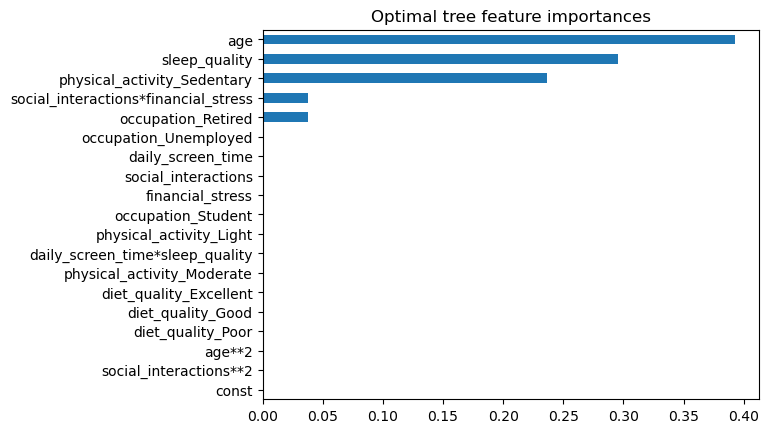

In [223]:
# Plot importances
pd.Series(tree_reg.feature_importances_, index=X_train.columns).sort_values().plot(kind='barh')
plt.title('Optimal tree feature importances')
plt.show()

> ### Explanation
> - **"age"** appears to be a feature of much importance because it's quite impactful for the decision tree, and influential for LASSO. Despite the fact that it has one of the lower p-values.
> - **"physical_activity_Sedentary"** appears to be another very important feature because it's most statistically significant, it has the most influential coefficient for LASSO, and it has one of the greatest importances for the decision tree.
> - **"sleep_quality"** appears to be influential because it's one of the most important for the decision tree, it's very statistically significant, and it's impactful to LASSO.
> - **"diet_quality_Excellent"** doesn't appear to be important because it isn't statistically significant, and it isn't important to the decision tree and LASSO.
> - **"diet_quality_Good"** doesn't appear to be important because it isn't statistically significant, it isn't important to the dicision tree, and it isn't very important to LASSO.
> - **"occupation_Unemployed"** doesn't appear to be important because it isn't statistically significant and it isn't very important to the dicision tree or LASSO.

Problem 10. You recieve a new data point. The new data point can be found at

https://richardson.byu.edu/220/stress_new.csv

Using the final linear regression from problem 5, predict what this individual's stress level will be.

In [233]:
# Import and show the new point
new_point = pd.read_csv('https://richardson.byu.edu/220/stress_new.csv')
new_point

,age,occupation,physical_activity,sleep_quality,daily_screen_time,social_interactions,financial_stress,diet_quality,stress_level_score
0,24,Professional,Light,9,7,2,4,Good,NaN


In [276]:
# Scale and show new point
new_point_scaled = new_point.drop(columns='stress_level_score', axis=1)
continuous_cols = new_point_scaled.select_dtypes(include=[np.number]).columns
new_point_scaled[continuous_cols] = scaler.transform(new_point_scaled[continuous_cols])
new_point_scaled

,age,occupation,physical_activity,sleep_quality,daily_screen_time,social_interactions,financial_stress,diet_quality
0,-1.312157,Professional,Light,-0.083316,0.922033,-0.407263,-0.470546,Good


In [282]:
# Manually finish creating the new point :)
new_values = {
    'const': [1.0],
    'age': [-1.312157],
    'sleep_quality': [-0.083316],
    'social_interactions': [-0.407263],
    'financial_stress': [-0.470546],
    'occupation_Student': [0],
    'physical_activity_Light': [1],
    'physical_activity_Moderate': [0],
    'physical_activity_Sedentary': [0],
    'age**2': [-1.312157**2],
    'social_interactions*financial_stress': [-0.407263*-0.470546],
}

new_point_processed = pd.DataFrame(new_values)
new_point_processed

,const,age,sleep_quality,social_interactions,financial_stress,occupation_Student,physical_activity_Light,physical_activity_Moderate,physical_activity_Sedentary,age**2,social_interactions*financial_stress
0,1.0,-1.312157,-0.083316,-0.407263,-0.470546,0,1,0,0,-1.721756,0.191636


In [285]:
print('----- Prediction information -----')
reduced_reg_higher_order.get_prediction(new_point_processed).summary_frame(alpha=0.05)

----- Prediction information -----


,mean,mean_se,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
0,2.46464,0.175847,2.11959,2.809691,-0.391858,5.321139


> ### Explanation
> The prediction for the new point is 2.46464

Problem 11. For the new individual introduced in problem 11, find a prediction interval for the stress level.

> ### Explanation
> The prediction interval is from -0.391858 to 5.321139

Problem 12. Use all the variables from the original model and add all 4 higher order terms from problem 5. Build a Bayesian linear regression model. Standardize the data and use N(0,1) priors for the variables.

In [296]:
# Show predictors
X_for_bayes = X_higher_order.drop(columns='const', axis=1)
X_for_bayes.head()

,age,sleep_quality,daily_screen_time,social_interactions,financial_stress,occupation_Retired,occupation_Student,occupation_Unemployed,physical_activity_Light,physical_activity_Moderate,physical_activity_Sedentary,diet_quality_Excellent,diet_quality_Good,diet_quality_Poor,age**2,social_interactions**2,daily_screen_time*sleep_quality,social_interactions*financial_stress
0,1.410805,-0.083316,0.922033,-0.407263,-0.470546,0,0,0,0,0,1,0,1,0,1.990370,0.165863,-0.076820,0.191636
1,-0.780848,-0.083316,-1.005295,-1.065911,-0.937932,1,0,0,0,0,1,1,0,0,0.609723,1.136167,0.083757,0.999752
2,-0.448779,-0.083316,0.922033,-0.407263,-0.003160,0,0,0,0,0,1,0,1,0,0.201403,0.165863,-0.076820,0.001287
3,0.281772,0.651076,-0.523463,0.251385,-0.937932,0,0,0,1,0,0,0,1,0,0.079395,0.063194,-0.340814,-0.235782
4,1.410805,-0.083316,-1.005295,-1.065911,1.866383,0,0,1,0,1,0,0,0,0,1.990370,1.136167,0.083757,-1.989399


In [298]:
# Create and print the priors
priors = {var:bmb.Prior("Normal", mu = 0, sigma = 1) for var in X_for_bayes.columns}

# Add the intercept
priors["Intercept"] = bmb.Prior("Normal",mu = 0,sigma = 1)

print('----- Priors -----')
priors

----- Priors -----


{'age': Normal(mu: 0.0, sigma: 1.0),
 'sleep_quality': Normal(mu: 0.0, sigma: 1.0),
 'daily_screen_time': Normal(mu: 0.0, sigma: 1.0),
 'social_interactions': Normal(mu: 0.0, sigma: 1.0),
 'financial_stress': Normal(mu: 0.0, sigma: 1.0),
 'occupation_Retired': Normal(mu: 0.0, sigma: 1.0),
 'occupation_Student': Normal(mu: 0.0, sigma: 1.0),
 'occupation_Unemployed': Normal(mu: 0.0, sigma: 1.0),
 'physical_activity_Light': Normal(mu: 0.0, sigma: 1.0),
 'physical_activity_Moderate': Normal(mu: 0.0, sigma: 1.0),
 'physical_activity_Sedentary': Normal(mu: 0.0, sigma: 1.0),
 'diet_quality_Excellent': Normal(mu: 0.0, sigma: 1.0),
 'diet_quality_Good': Normal(mu: 0.0, sigma: 1.0),
 'diet_quality_Poor': Normal(mu: 0.0, sigma: 1.0),
 'age**2': Normal(mu: 0.0, sigma: 1.0),
 'social_interactions**2': Normal(mu: 0.0, sigma: 1.0),
 'daily_screen_time*sleep_quality': Normal(mu: 0.0, sigma: 1.0),
 'social_interactions*financial_stress': Normal(mu: 0.0, sigma: 1.0),
 'Intercept': Normal(mu: 0.0, sigma:

In [301]:
# Prepare data frame
bayes_df = pd.concat([X_for_bayes, y], axis=1)

In [305]:
# Create formula
formula = create_bambi_formula(bayes_df, 'stress_level_score')

print('----- Formula -----')
print(formula)

----- Formula -----
stress_level_score ~ age + sleep_quality + daily_screen_time + social_interactions + financial_stress + occupation_Retired + occupation_Student + occupation_Unemployed + physical_activity_Light + physical_activity_Moderate + physical_activity_Sedentary + diet_quality_Excellent + diet_quality_Good + diet_quality_Poor + `age**2` + `social_interactions**2` + `daily_screen_time*sleep_quality` + `social_interactions*financial_stress`


In [307]:
# Fit model and show results
bayes_regressor = bmb.Model(formula, bayes_df)
bayes_regressor.set_priors(priors=priors)
results = bayes_regressor.fit(draws=200, chains=2)
az.summary(results)

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [sigma, Intercept, age, sleep_quality, daily_screen_time, social_interactions, financial_stress, occupation_Retired, occupation_Student, occupation_Unemployed, physical_activity_Light, physical_activity_Moderate, physical_activity_Sedentary, diet_quality_Excellent, diet_quality_Good, diet_quality_Poor, age**2, social_interactions**2, daily_screen_time*sleep_quality, social_interactions*financial_stress]


Output()

Sampling 2 chains for 1_000 tune and 200 draw iterations (2_000 + 400 draws total) took 33 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma,1.457,0.028,1.411,1.518,0.001,0.001,761.0,193.0,1.00
Intercept,1.350,0.161,1.000,1.631,0.009,0.006,344.0,333.0,1.00
age,0.163,0.050,0.057,0.244,0.003,0.002,305.0,261.0,1.00
sleep_quality,-0.255,0.043,-0.335,-0.174,0.002,0.001,769.0,231.0,1.00
daily_screen_time,0.104,0.059,-0.007,0.210,0.003,0.002,508.0,363.0,1.00
social_interactions,-0.201,0.060,-0.326,-0.095,0.004,0.003,272.0,219.0,1.00
financial_stress,-0.160,0.048,-0.242,-0.075,0.002,0.002,477.0,334.0,1.00
occupation_Retired,-0.031,0.160,-0.338,0.256,0.007,0.007,511.0,321.0,1.02
occupation_Student,-0.154,0.098,-0.345,0.030,0.003,0.003,962.0,324.0,1.01
occupation_Unemployed,-0.179,0.131,-0.417,0.054,0.006,0.005,502.0,347.0,1.00


**Part 2** A successful video game streamer is defined as someone who has over 1,000 subscribers to their platform. A data set of several video game streamers who log at least 5 hours a week can be found at

https://richardson.byu.edu/220/game_stream.csv

The target variable is "success" and is either 1 or 0. The other variables are predictor varibales and include streaming hours, genre, interaction level, equipment quality, and social media presence.

First of all, a moment of silence for a whopping 47 streamers with more than 30 hours a week and less than 1,000 subscribers. Then get on with the rest of the problems!

Problem 13. Split the data into a training and test set. Fit a logistic regression model to the training set.

In [308]:
# Import and show data
streamer_data_raw = pd.read_csv('https://richardson.byu.edu/220/game_stream.csv')
streamer_data_raw.head()

,streaming_hours,game_genre,interaction_level,equipment_quality,social_media_presence,years_experience,success
0,17,Other,6,Low,8,10,1
1,13,Other,1,High,6,8,1
2,10,Other,9,Medium,9,6,1
3,20,Sports,8,Low,1,4,0
4,37,Adventure,10,High,4,10,1


In [315]:
# Split into X and y and prepair the predictors
target = 'success'
X = sm.add_constant(streamer_data_raw.drop(columns=target))

# Dummify the categorical columns
X = pd.get_dummies(X, drop_first=True)

# Replace False with 0 and True with 1
X = X.replace({False: 0, True: 1})

y = streamer_data_raw[target]

In [316]:
# Show predictors
X.head()

,const,streaming_hours,interaction_level,social_media_presence,years_experience,game_genre_Adventure,game_genre_Other,game_genre_Sports,game_genre_Strategy,equipment_quality_Low,equipment_quality_Medium
0,1.0,17,6,8,10,0,1,0,0,1,0
1,1.0,13,1,6,8,0,1,0,0,0,0
2,1.0,10,9,9,6,0,1,0,0,0,1
3,1.0,20,8,1,4,0,0,1,0,1,0
4,1.0,37,10,4,10,1,0,0,0,0,0


In [317]:
# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=train_test_random_state)

In [319]:
logistic_reg = sm.Logit(y_train, X_train).fit()
logistic_reg.summary()

Optimization terminated successfully.
         Current function value: 0.154952
         Iterations 10


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                success   No. Observations:                  800
Model:                          Logit   Df Residuals:                      789
Method:                           MLE   Df Model:                           10
Date:                Wed, 18 Dec 2024   Pseudo R-squ.:                  0.6965
Time:                        20:24:20   Log-Likelihood:                -123.96
converged:                       True   LL-Null:                       -408.50
Covariance Type:            nonrobust   LLR p-value:                7.392e-116
============================================================================================
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                       -6.3444      0.969     -6.547      0.000      -8.244      -4.445
streaming_hours              0.0375      0.016      2.280      0.023       0.005       0.070
interaction_level            0.3132      0.062      5.026      0.000       0.191       0.435
social_media_presence        1.9931      0.196     10.154      0.000       1.608       2.378
years_experience             0.0597      0.056      1.068      0.286      -0.050       0.169
game_genre_Adventure        -0.3168      0.518     -0.612      0.541      -1.332       0.698
game_genre_Other            -0.6800      0.533     -1.277      0.202      -1.724       0.364
game_genre_Sports            0.5683      0.527      1.078      0.281      -0.465       1.601
game_genre_Strategy         -0.0393      0.517     -0.076      0.939      -1.052       0.974
equipment_quality_Low       -0.9652      0.410     -2.352      0.019      -1.770      -0.161
equipment_quality_Medium    -1.4321      0.422     -3.396      0.001      -2.259      -0.605
============================================================================================

Possibly complete quasi-separation: A fraction 0.31 of observations can be
perfectly predicted. This might indicate that there is complete
quasi-separation. In this case some parameters will not be identified.
"""

Problem 14. Fit a classification tree to the training set.

In [325]:
# Create lists
max_depths = []
tree_r2s = []

# Loop through the depths
for depth in range(2, 21):
	# Declare and fit tree
	tree_model = DecisionTreeClassifier(max_depth = depth)
	tree_model.fit(X_train, y_train)

	# Calculate r2 and append to list
	tree_r2 = calculateR2(tree_model, X_test, y_test)
	tree_r2s.append(tree_r2)

	# Append max depth
	max_depths.append(depth)

# Display r2s as a table
dic = {
    'Max depth': max_depths,
    'Out of sample R^2': tree_r2s,
}
df = pd.DataFrame(dic)
df

,Max depth,Out of sample R^2
0,2,0.605211
1,3,0.473615
2,4,0.473615
3,5,0.420976
4,6,0.473615
5,7,0.447296
6,8,0.473615
7,9,0.499934
8,10,0.473615
9,11,0.552573


In [342]:
tree_clf = DecisionTreeClassifier(max_depth=14)
tree_clf.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=14)

Problem 15. Use out of sample AUC to compare the logistic regression model and the classification tree.

In [343]:
# Calculate the AUCs
logistic_reg_auc = roc_auc_score(y_test, logistic_reg.predict(X_test))
tree_auc = roc_auc_score(y_test, tree_clf.predict_proba(X_test)[:, 1])

In [344]:
# Show results as a table
dict = {
    'Logistic regressor': [logistic_reg_auc],
    'Decision tree classifier': [tree_auc],
}

df = pd.DataFrame(dict).T
df.columns = ['AUC']
df

,AUC
Logistic regressor,0.971180
Decision tree classifier,0.874852


> ### Explanation
> The logistic regressor preforms better across different thresholds than the decision tree does.

Problem 16. For the classification tree model, compute the confusion matrix for the predicted vales. These values automatically use 0.5 as a cut-off. Change the prediction cut-off to 0.6 and compute the confusion matrix again.

In [373]:
# Calculate and display the confusion matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, tree_clf.predict_proba(X_test)[:,1] > 0.5)

print('----- Confusion matrix with a threshold of 0.5 -----')
print(cm)

----- Confusion matrix with a threshold of 0.5 -----
[[ 42   9]
 [ 11 138]]


In [372]:
# Calculate and display the confusion matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, tree_clf.predict_proba(X_test)[:,1] > 0.6)

print('----- Confusion matrix with a threshold of 0.6 -----')
print(cm)

----- Confusion matrix with a threshold of 0.6 -----
[[ 42   9]
 [ 11 138]]
